##1. Exploración y perfilamiento de los datos

###1.1 Importación de librerías

#####Se investigó el uso de la librería ydata-profiling, la cual permite generar reportes automáticos de análisis exploratorio de datos (EDA), facilitando la identificación de estadísticas descriptivas, valores faltantes, distribuciones y relaciones entre variables. Esta herramienta puede ahorrar una cantidad significativa de tiempo en la etapa de exploración inicial del dataset. Sin embargo, con el fin de realizar un análisis más detallado y comprender de manera práctica cada uno de los pasos del proceso de exploración, en este proyecto el análisis exploratorio se desarrollará de forma manual y paso a paso utilizando las herramientas de pandas y otras librerías de visualización.

In [ ]:
#!pip install ydata-profiling  # Instala la librería ydata-profiling, utilizada para generar reportes automáticos de análisis exploratorio de datos (EDA)

#####Para el desarrollo del análisis se utilizaron librerías del ecosistema de Python orientadas al análisis de datos y aprendizaje automático. Pandas y NumPy se emplearon para la manipulación y procesamiento de los datos; Matplotlib y Seaborn para la visualización; y la librería Scikit-learn para la construcción, entrenamiento y evaluación de los modelos de clasificación, incluyendo árboles de decisión y K-vecinos más cercanos.

In [ ]:
import pandas as pd  # Librería principal para manipulación y análisis de datos en estructuras tipo DataFrame
import numpy as np   # Librería para operaciones numéricas y manejo eficiente de arreglos y cálculos matemáticos

import matplotlib.pyplot as plt  # Librería base para crear gráficos y visualizar datos
import seaborn as sns            # Librería de visualización basada en matplotlib que permite generar gráficos estadísticos más claros y estéticos

from sklearn.pipeline import Pipeline  # Permite construir un flujo de trabajo organizado que aplica pasos de preprocesamiento y entrenamiento del modelo de forma secuencial
from sklearn.compose import ColumnTransformer  # Permite aplicar diferentes transformaciones a distintos tipos de variables (por ejemplo numéricas y categóricas)
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # StandardScaler normaliza variables numéricas; OneHotEncoder convierte variables categóricas en variables binarias
from sklearn.model_selection import train_test_split  # Permite dividir el dataset en conjunto de entrenamiento y prueba para evaluar el modelo correctamente

from sklearn.tree import DecisionTreeClassifier, plot_tree  # DecisionTreeClassifier construye el modelo de árbol de decisión; plot_tree permite visualizar gráficamente la estructura del árbol
from sklearn.model_selection import GridSearchCV  # Permite buscar automáticamente la mejor combinación de hiperparámetros del modelo mediante validación cruzada
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # Métricas de evaluación del modelo para medir su rendimiento en clasificación

from sklearn.neighbors import KNeighborsClassifier  # Implementación del algoritmo K-vecinos más cercanos (KNN) para clasificación basada en similitud entre observaciones

from sklearn.tree import export_text  # Permite extraer las reglas del árbol de decisión en formato texto para interpretar las condiciones de clasificación

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix  # Herramientas para evaluar el modelo: reporte de métricas, matriz de confusión y visualización de errores de clasificación

#from ydata_profiling import ProfileReport  # Herramienta para generar automáticamente un informe exploratorio del dataset, mostrando distribuciones, valores faltantes, correlaciones y estadísticas descriptivas (Se usa solo como ejemplo)

###1.2 Carga del dataset

#####Se carga el dataset desde el pc

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (4).csv


#####Como el archivo esta guardado en otra codificación, se usa el "encoding=latin1", para poder leer el archivo

In [ ]:
df = pd.read_csv("dataset.csv", sep=";", encoding="latin1")

###1.3 Generación del posible perfil del dataset

#####En esta sección se utiliza la librería ydata-profiling para generar un reporte automático del conjunto de datos. Este informe permite obtener de manera rápida información relevante sobre las variables, como estadísticas descriptivas, distribución de los datos, valores faltantes, correlaciones y posibles valores atípicos.

In [ ]:
#profile = ProfileReport(df, title="Perfil del dataset", explorative=True)
#profile

#####A continuación, se procede a hacer el análisis exploratorio de forma manual

###1.4 Dimensión del dataset

In [ ]:
df.shape

(1990, 13)

#####Se observa que el conjunto de datos contiene 1990 registros y 13 variables. Esto indica que se dispone de un número considerable de observaciones para entrenar modelos de aprendizaje automático orientados a la clasificación del riesgo de hipertensión. Cada registro representa información asociada a un paciente, incluyendo variables relacionadas con características demográficas, hábitos de vida y variables clínicas

###1.5 Información general del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   object 
 7   Historia_Familiar   1990 non-null   object 
 8   Actividad_Fisica    1990 non-null   object 
 9   Fumador             1990 non-null   object 
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   object 
 12  Hipertension        1990 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 202.2+ KB


#####Se puede observar la estructura general del dataframe, incluyendo los tipos de datos y la cantidad de valores no nulos en cada variable. En este caso, todas las variables presentan 1990 valores no nulos, lo que indica que no existen valores faltantes en el dataset. Esto es positivo para el proceso de modelado, ya que no será necesario aplicar técnicas de imputación para completar información faltante.

También se observa que el conjunto de datos contiene diferentes tipos de variables:

* Variables numéricas (int64 y float64): Edad, Ingesta_Sal, Nivel_Stres, Colesterol, Duración_Sueño, BMI y Glucosa.

* Variables categóricas (object): Medicación, Historia_Familiar, Actividad_Fisica, Fumador, Enfermedad_Corazon e Hipertension.

La variable Hipertension corresponde a la variable objetivo, ya que es la que se pretende predecir mediante los modelos de clasificación.

#####Un aspecto relevante que se puede observar es que la variable Ingesta_Sal aparece como numérica (float64), mientras que en el diccionario de datos se describe como una variable categórica con tres niveles. Esta inconsistencia deberá analizarse posteriormente durante la etapa de preparación de los datos para decidir si la variable puede utilizarse o si debe excluirse del análisis.

###1.6 Estadísticas descriptivas

In [ ]:
df.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
mean,50.379397,8.531608,4.974372,209.526935,6.452613,26.013869,105.642211
std,19.439669,1.994245,3.144396,75.791456,1.540354,4.507425,22.541122
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.325000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


#####Se obtienen estadísticas descriptivas de las variables numéricas del dataset, tales como el número de observaciones, la media, la desviación estándar, los valores mínimos y máximos, así como los cuartiles. Este análisis permite tener una primera aproximación al comportamiento de las variables del conjunto de datos.

En primer lugar, se observa que todas las variables numéricas presentan 1990 registros, lo cual coincide con el tamaño total del dataset. Esto confirma que no existen valores faltantes en estas variables.

Analizando algunas variables en particular, se puede observar que la edad de los pacientes tiene un promedio aproximado de 50 años, con valores que oscilan entre 18 y 84 años, lo cual sugiere que el dataset incluye pacientes adultos en diferentes rangos de edad.

En el caso de la variable colesterol, se observa una media cercana a 209 mg/dL. Según la American Heart Association (2023), los niveles de colesterol total menores a 200 mg/dL se consideran deseables, entre 200 y 239 mg/dL se consideran en el límite alto y valores iguales o superiores a 240 mg/dL se consideran altos. En el dataset se observa un valor máximo de aproximadamente 2360 mg/dL, lo cual se encuentra muy por encima de los rangos clínicos habituales, sugiriendo la posible presencia de datos anomalos que deberán analizarse posteriormente.

Respeco a la variable Glucosa, se observa un promedio cercano a 105.64 mg/dL, con valores mínimos de 70 mg/dL y máximos de aproximadamente 196 mg/dL. De acuerdo con la American Diabetes Association (2023), los niveles de glucosa en ayunas menores a 100 mg/dL se consideran normales, valores entre 100 y 125 mg/dL corresponden a prediabetes y valores iguales o superiores a 126 mg/dL pueden indicar diabetes. Bajo estos criterios, los valores presentes en el dataset se encuentran dentro de rangos clínicamente posibles, aunque los valores más altos podrían corresponder a pacientes con hiperglucemia o diabetes. Por lo tanto, no se identifican valores claramente imposibles desde el punto de vista fisiológico.

Para la variable Duración_Sueño se observa un promedio cercano a 6.45 horas, con valores mínimos de aproximadamente 1.5 horas y máximos de 11.4 horas. De acuerdo con la National Sleep Foundation (2020), los adultos requieren entre 7 y 9 horas de sueño por noche para mantener un adecuado funcionamiento físico y cognitivo. En este contexto, el promedio observado en el dataset se encuentra ligeramente por debajo de las recomendaciones, lo cual podría indicar que una parte de la población presenta patrones de sueño reducidos. Aunque se identifican valores bajos cercanos a 2 horas, estos pueden ser poco frecuentes pero no necesariamente corresponden a errores de registro, ya que podrían reflejar episodios de sueño muy limitado. Dado que no se cuenta con información adicional sobre el procedimiento de medición de esta variable, no se considera apropiado realizar imputaciones ni modificaciones sobre estos valores extremos. Por lo tanto, la variable se mantendrá en su forma original para el análisis posterior.

Finalmente, variables como BMI presenta valores que oscilan entre aproximadamente 11.9 y 41.9. Según la Organización Mundial de la Salud (2024), un índice de masa corporal inferior a 18.5 se clasifica como bajo peso, entre 18.5 y 24.9 se considera normal, entre 25 y 29.9 corresponde a sobrepeso y valores iguales o superiores a 30 indican obesidad. En este contexto, el valor máximo registrado en el dataset podría corresponder a casos de obesidad severa, lo cual es clínicamente posible. Sin embargo, el valor mínimo observado resulta considerablemente bajo para población adulta, lo que podría sugerir la presencia de registros atípicos, pero posibles.

###1.7 Identificación de valores nulos

In [ ]:
df.isnull().sum()

,0
Edad,0
Ingesta_Sal,0
Nivel_Stres,0
Colesterol,0
Duración_Sueño,0
BMI,0
Medicación,0
Historia_Familiar,0
Actividad_Fisica,0
Fumador,0


#####Se verifica la presencia de valores faltantes. Los resultados muestran que ninguna de las variables presenta valores nulos, ya que todas reportan un conteo de cero.

Esto indica que el conjunto de datos se encuentra completo en términos de información, por lo que no será necesario aplicar técnicas de imputación de datos faltantes durante la fase de preparación del dataset.

###1.8 Identificación de registros duplicados

##### Se verifica la presencia de registros duplicados en el dataset. El resultado indica que existen 4 registros duplicados dentro del conjunto de datos

In [ ]:
df.duplicated().sum()

np.int64(4)

##### Posteriormente, se visualizaron estos registros, lo cual permitió identificar las filas específicas que presentan la misma información en todas sus variables.

In [ ]:
df[df.duplicated()]

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
167,79,10.8,0,249.5,6.7,24.8,Ninguna,Si,Baja,No,126.0,No,Si
971,66,5.8,9,183.7,6.6,25.8,Ninguna,No,Moderada,No,86.5,No,No
1172,52,7.5,2,229.4,7.0,26.7,BloqueadorBeta,Si,Moderada,No,118.9,No,Si
1346,56,9.4,0,186.6,6.6,24.7,BloqueadorBeta,No,Baja,No,97.8,No,No


#####La presencia de registros duplicados puede generar sesgos en el entrenamiento de los modelos de aprendizaje automático, ya que algunas observaciones tendrían mayor peso en el proceso de aprendizaje del algoritmo. Por esta razón, se elimina este tipo de registros

###1.9 Distribución de variables numéricas

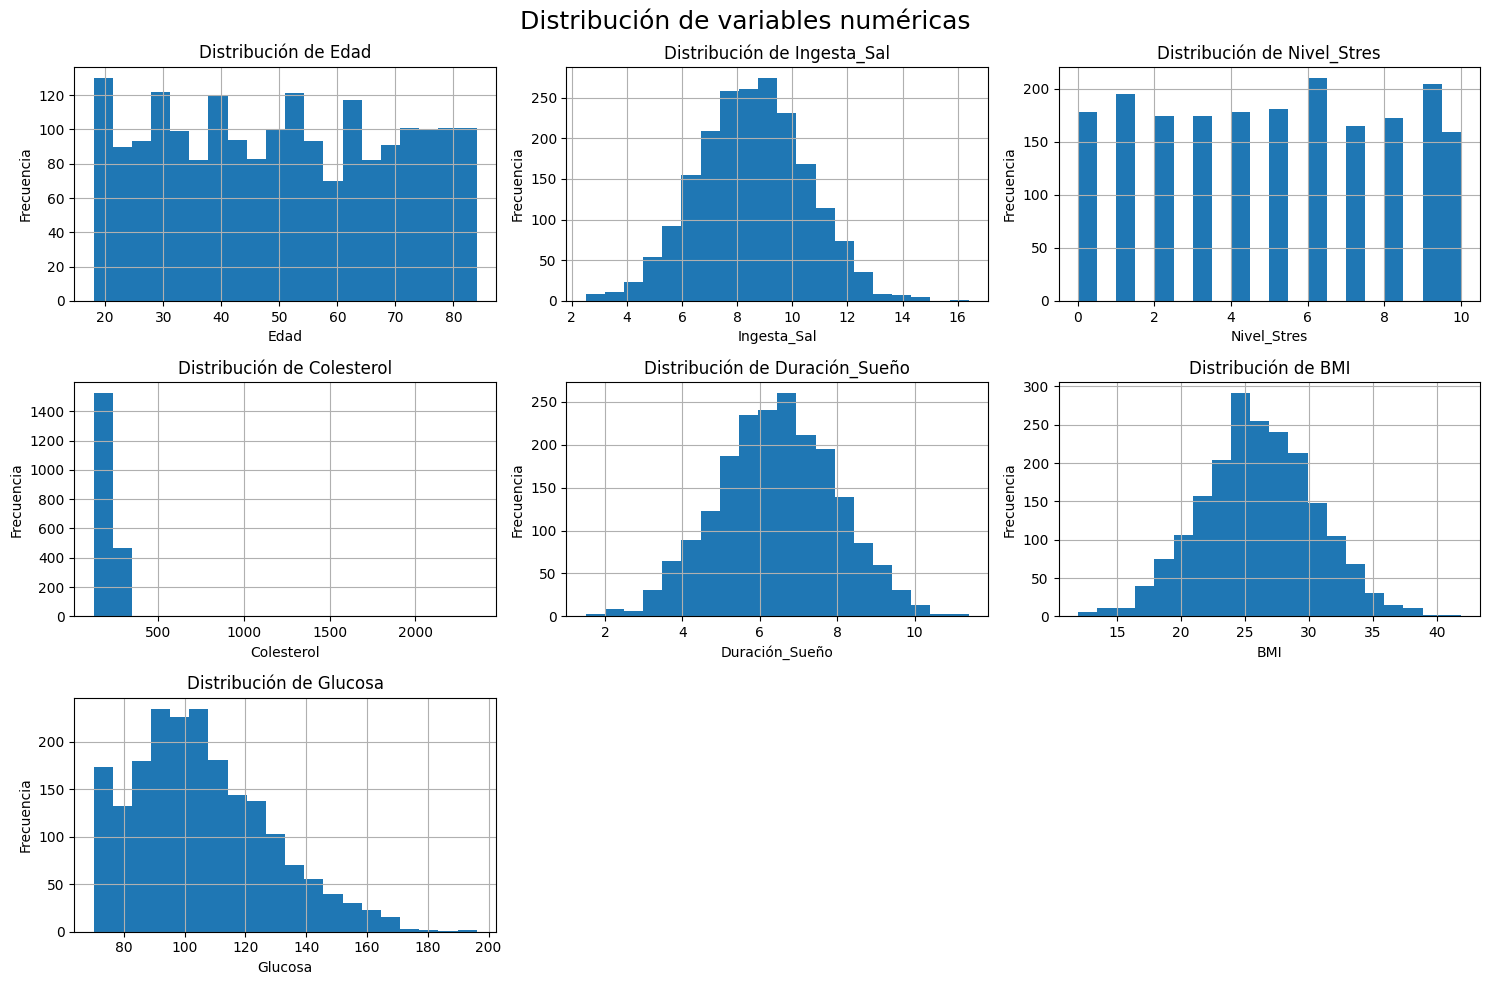

In [ ]:
axes = df.hist(figsize=(15,10), bins=20) #Generar histogramas de las variables numéricas

for ax in axes.ravel(): #Recorrer cada gráfico para personalizar título y ejes
    variable = ax.get_title()                     # obtiene el nombre de la variable
    ax.set_title(f"Distribución de {variable}")   # título del gráfico
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables numéricas", fontsize=18)
plt.tight_layout()
plt.show()

#####Con el fin de comprender mejor el comportamiento de las variables numéricas presentes en el dataset, se generaron histogramas para visualizar su distribución. Este tipo de visualización permite identificar patrones en los datos, así como la forma de las distribuciones y la posible presencia de valores atípicos que podrían influir en el entrenamiento de los modelos.

En primer lugar, la variable Edad presenta una distribución relativamente uniforme a lo largo de los diferentes rangos etarios, lo que sugiere que el dataset incluye pacientes adultos distribuidos en distintos grupos de edad. Esta característica es favorable para el análisis, ya que evita una concentración excesiva de observaciones en un único rango etario.

La variable Ingesta_Sal muestra una distribución aproximadamente normal, con una mayor concentración de observaciones alrededor de valores intermedios. Esto indica que la mayoría de los pacientes presentan niveles moderados de consumo de sal, mientras que los valores extremos son menos frecuentes.

En el caso de Nivel_Stres, se observa que los valores se distribuyen de forma relativamente homogénea dentro del rango entre 0 y 10, lo cual sugiere que la variable podría corresponder a una escala ordinal utilizada para medir el nivel de estrés percibido por los pacientes.

La variable Colesterol presenta una distribución asimétrica hacia la derecha, con una alta concentración de observaciones en valores relativamente bajos y una cola que se extiende hacia valores más altos. Esta característica visual respalda la posible presencia de valores extremos identificados previamente en el análisis descriptivo.

Para Duración_Sueño, la distribución muestra una forma cercana a una campana, con una concentración de observaciones en torno a valores intermedios. Esto sugiere que la mayoría de los pacientes presenta patrones de sueño dentro de rangos similares, aunque existen algunos valores bajos que representan una menor cantidad de horas de descanso.

Por su parte, la variable BMI presenta una distribución aproximadamente normal, con mayor densidad de observaciones en valores intermedios y menor frecuencia en los extremos.

Finalmente, la variable Glucosa muestra una distribución ligeramente sesgada hacia valores más altos, lo cual podría reflejar la presencia de pacientes con niveles elevados de glucosa en sangre dentro del dataset.

En conjunto, el análisis visual de las distribuciones permite complementar la información obtenida en las estadísticas descriptivas, proporcionando una mejor comprensión de la forma y variabilidad de las variables, aspectos que resultan relevantes para las etapas posteriores de limpieza, transformación y modelado de los datos.

###1.10 Distribución de la variable objetivo

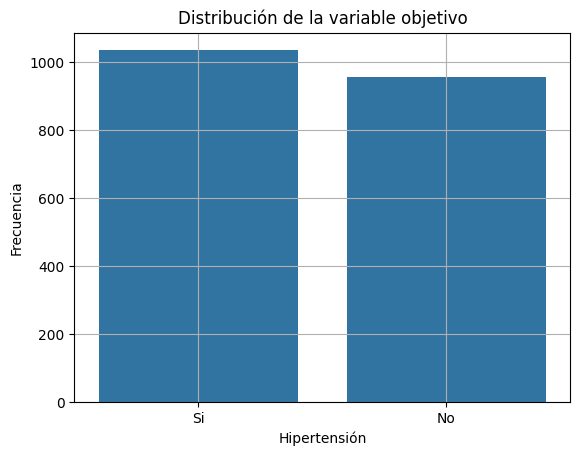

In [ ]:
sns.countplot(x="Hipertension", data=df)
plt.grid(True)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Hipertensión")
plt.ylabel("Frecuencia")
plt.show()

#####Con el objetivo de analizar la distribución de la variable objetivo, se generó un gráfico de conteo para la variable Hipertension, la cual indica si un paciente presenta o no esta condición.

A partir de la gráfica se observa que ambas categorías (Sí y No) presentan una cantidad de registros relativamente similar. Esto indica que el dataset se encuentra razonablemente balanceado, lo cual es una característica favorable para el entrenamiento de modelos de clasificación

###1.11 Distribución de variables categóricas

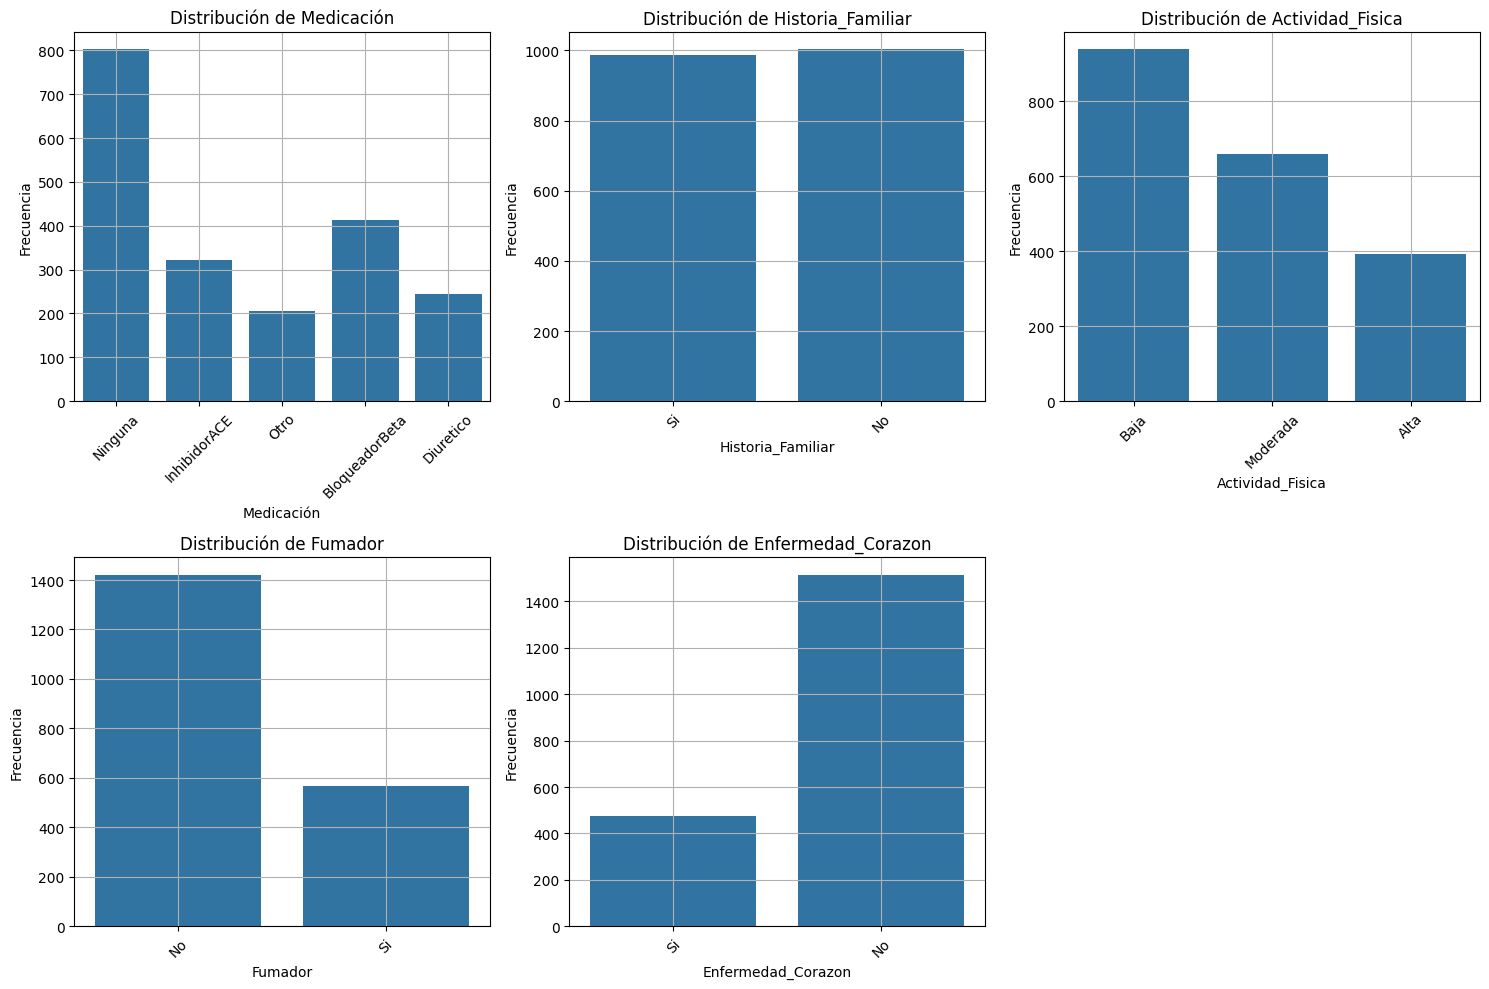

In [ ]:
categoricas = ["Medicación","Historia_Familiar","Actividad_Fisica","Fumador","Enfermedad_Corazon"]

plt.figure(figsize=(15,10))

for i, col in enumerate(categoricas, 1):
    plt.subplot(2,3,i) # Crea un espacio para cada gráfico dentro de una cuadrícula de 2 filas y 3 columnas
    sns.countplot(x=col, data=df)
    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.grid(True)

plt.tight_layout()
plt.show()

#####Con el objetivo de analizar la distribución de las variables categóricas presentes en el dataset, se generaron gráficos de conteo que permiten observar la frecuencia de cada categoría.

En la variable Medicación, la categoría Ninguna concentra una proporción considerable de los registros, lo que sugiere que una parte importante de los pacientes no se encuentra bajo tratamiento farmacológico al momento del registro. Desde la perspectiva del modelado, esta variable podría capturar información relacionada con el estado clínico del paciente o con la presencia de condiciones cardiovasculares previas.

La variable Historia_Familiar presenta una distribución relativamente equilibrada entre las categorías Sí y No, lo cual resulta favorable desde el punto de vista del aprendizaje automático, ya que evita un desbalance marcado entre las clases dentro de esta característica.

En la variable Actividad_Física, se observa que una mayor proporción de pacientes se concentra en los niveles bajo y moderado, mientras que la categoría alta presenta una menor frecuencia. Esta distribución podría reflejar diferentes patrones de estilo de vida en la población analizada, los cuales podrían estar relacionados con factores de riesgo cardiovascular.

Para la variable Fumador, la mayoría de los registros corresponde a pacientes no fumadores. Aunque se observa cierto desbalance entre las categorías, la presencia de una cantidad considerable de individuos fumadores permite que esta variable pueda aportar información relevante durante el proceso de modelado.

Finalmente, en la variable Enfermedad_Corazon predomina la categoría No, lo cual es consistente con datasets poblacionales donde la mayoría de los individuos no presenta enfermedad cardíaca diagnosticada. No obstante, la presencia de pacientes con esta condición podría aportar información relevante para identificar posibles asociaciones con el riesgo de hipertensión.

###1.12 Correlación entre variables numéricas

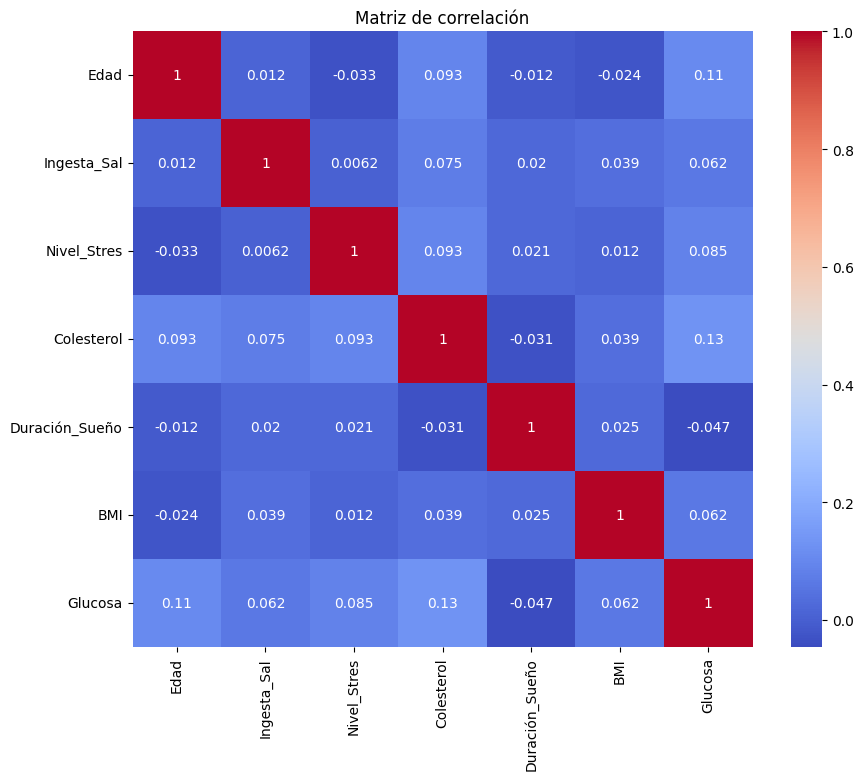

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

#####Con el objetivo de analizar la relación entre las variables numéricas del dataset, se generó una matriz de correlación utilizando el coeficiente de correlación de Pearson, la cual permite identificar posibles relaciones lineales entre las variables.

En general, se observa que las correlaciones entre las variables numéricas son bajas, con valores cercanos a cero en la mayoría de los casos. Esto sugiere que no existe una relación lineal fuerte entre estas características, por lo que no se evidencia una multicolinealidad significativa dentro del conjunto de variables analizadas.

Las correlaciones más altas se observan entre Glucosa y Colesterol (0.13) y entre Edad y Glucosa (0.11). Sin embargo, estos valores siguen siendo relativamente bajos, lo que indica que las variables presentan una baja dependencia lineal entre sí.

En este contexto, cada una de las variables numéricas podría aportar información complementaria al modelo, ya que no existe una relación lineal fuerte que sugiera redundancia entre ellas.

###1.13 Identificación de valores extremos

#####Para identificar posibles valores atípicos en las variables numéricas se utilizó el método del rango intercuartílico (IQR). A partir de los cuartiles Q1 y Q3 se calcularon los límites inferior y superior definidos como:

- Límite inferior: ( Q1 - 1.5 * IQR )  
- Límite superior: ( Q3 + 1.5 * IQR )



In [ ]:
numericas = df.select_dtypes(include=['int64','float64'])  # Seleccionar únicamente las columnas numéricas

Q1 = numericas.quantile(0.25)  # Calcular el primer cuartil (percentil 25) de cada variable
Q3 = numericas.quantile(0.75)  # Calcular el tercer cuartil (percentil 75) de cada variable
IQR = Q3 - Q1  # Calcular el rango intercuartílico (IQR)

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((numericas < limite_inferior) | (numericas > limite_superior))  # Identificar los valores que están fuera de los límites establecidos

outliers.sum()  # Contar la cantidad de valores extremos detectados en cada variable numérica

,0
Edad,0
Ingesta_Sal,17
Nivel_Stres,0
Colesterol,4
Duración_Sueño,12
BMI,16
Glucosa,17


#####Posteriormente, se identificaron los registros que se encontraban fuera de estos límites y se contabilizó la cantidad de outliers presentes en cada variable numérica.

In [ ]:
for col in numericas.columns:
    valores = df.loc[outliers[col], col]
    if len(valores) > 0:
        print(f"\n{col} ({len(valores)} outliers):")
        print(valores.to_list())


Ingesta_Sal (17 outliers):
[2.8, 2.7, 14.9, 3.1, 14.8, 2.6, 2.5, 14.0, 14.7, 14.4, 14.5, 3.0, 16.4, 2.5, 2.8, 2.7, 14.2]

Colesterol (4 outliers):
[2360.0, 1597.0, 1835.0, 326.3]

Duración_Sueño (12 outliers):
[2.2, 10.8, 1.6, 2.0, 2.2, 11.0, 1.5, 11.4, 2.0, 1.7, 2.2, 11.0]

BMI (16 outliers):
[13.4, 12.0, 41.3, 13.4, 39.0, 12.8, 40.2, 11.9, 41.9, 13.3, 13.4, 13.8, 38.3, 12.9, 38.4, 12.4]

Glucosa (17 outliers):
[175.3, 192.7, 166.4, 180.5, 182.3, 170.5, 175.3, 172.0, 186.7, 166.7, 167.4, 168.1, 166.2, 170.3, 196.1, 166.1, 169.6]


#####Aunque el método IQR permitió identificar varios valores atípicos, no todos corresponden necesariamente a errores de registro. En variables clínicas como glucosa, BMI o duración del sueño, los valores extremos pueden representar condiciones reales de los pacientes. Sin embargo, en la variable colesterol se detectaron valores extremadamente elevados que exceden ampliamente los rangos fisiológicos plausibles (2360, 1597, 1835), por lo que estos registros se considerarán anomalías y serán eliminados en la etapa de limpieza de datos.

#####Finalmente, se visualizan estos valores mediante diagramas de caja (boxplots), lo que facilita observar la dispersión de los datos y la presencia de valores atípicos.

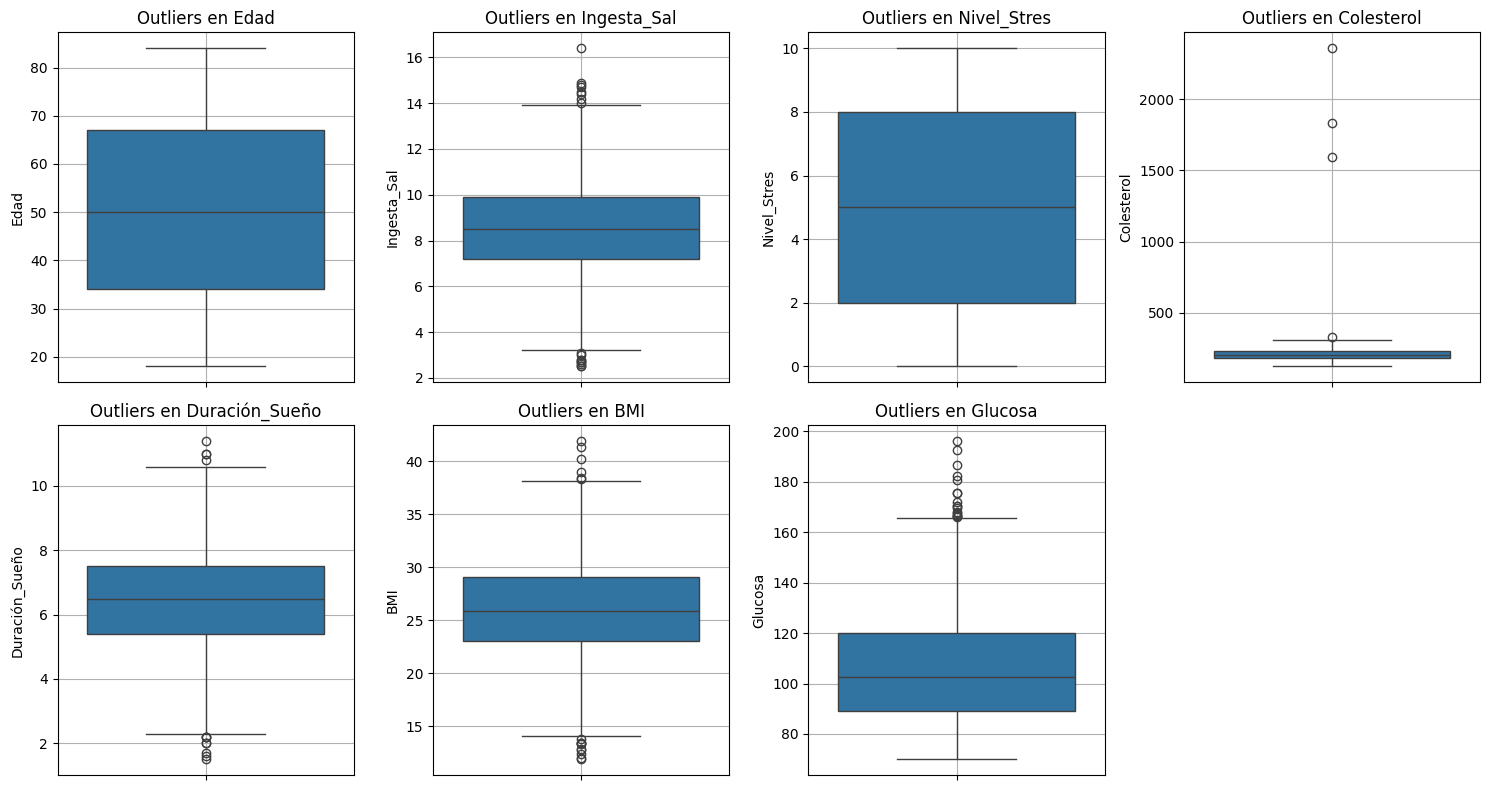

In [ ]:
plt.figure(figsize=(15,8)) # Crear una figura grande para mostrar todos los boxplots

for i, col in enumerate(numericas, 1): # Crear un boxplot para cada variable numérica
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col]) # Crear el boxplot de la variable
    plt.title(f"Outliers en {col}")
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

#####Los resultados muestran que algunas variables presentan valores extremos en diferentes magnitudes. En particular, la variable Colesterol presenta observaciones considerablemente alejadas del rango principal de la distribución, incluyendo valores muy superiores al resto de los datos. Estos resultados coinciden con lo observado previamente en el análisis descriptivo y sugieren la presencia de registros potencialmente anómalos que podrían corresponder a errores de medición o de registro.

También se identifican valores extremos en variables como Glucosa, BMI, Ingesta_Sal y Duración_Sueño. Sin embargo, en estos casos los valores se encuentran relativamente cercanos al rango principal de los datos y, considerando el contexto clínico de las variables, podrían representar variaciones reales dentro de la población analizada.

Desde la perspectiva del modelado, la presencia de outliers puede influir de manera diferente según el algoritmo utilizado. Por ejemplo, modelos basados en distancias, como K-Nearest Neighbors (KNN), pueden verse más afectados por valores extremos, mientras que modelos basados en árboles de decisión suelen ser más robustos frente a este tipo de observaciones.

Por lo tanto, en la etapa de preparación de los datos se evaluará el tratamiento de estos valores extremos. En particular, se considerará la eliminación de aquellos registros claramente anómalos, mientras que los valores extremos que puedan representar condiciones clínicas plausibles se mantendrán en el análisis.

##2. Preparación y limpieza de los datos

##### A partir de los resultados obtenidos en la etapa de exploración y perfilamiento de los datos, se identificaron algunos aspectos relacionados con la calidad del dataset que requieren tratamiento previo al entrenamiento de los modelos. En particular, se detectaron:

- inconsistencias en la variable Ingesta_Sal,
- presencia de registros duplicados,
- valores extremadamente anómalos en la variable Colesterol.

Con base en estos hallazgos, se procederá a construir un pipeline de preparación de los datos, el cual permitirá abordar estos aspectos de manera sistemática antes de la etapa de modelado.

###2.1 Eliminación de la variable Ingesta_Sal

#####Durante el análisis exploratorio se observó que la variable Ingesta_Sal aparece representada como numérica en el dataset, mientras que el diccionario de datos la define como una variable categórica con tres categorías.

Dado que no se conocen los intervalos que permitirían reconstruir dichas categorías, realizar una discretización podría introducir interpretaciones arbitrarias en los datos. Por esta razón se decide eliminar esta variable del análisis.

In [ ]:
df = df.drop(columns=["Ingesta_Sal"])

###2.2 Eliminación de registros duplicados

#####En la etapa de exploración se identificaron 4 registros duplicados dentro del dataset.

La presencia de observaciones duplicadas puede introducir sesgos en el proceso de aprendizaje de los modelos, ya que ciertos registros tendrían mayor influencia durante el entrenamiento. Por esta razón se procede a eliminar estos registros

In [ ]:
df = df.drop_duplicates()

#####Verificación

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(1986, 12)

###2.3 Eliminación de datos anómalos extremos

#####Durante el análisis exploratorio se detectaron valores extremos mediante el criterio del rango intercuartílico (IQR) y su visualización mediante diagramas boxplot.

Sin embargo, y como ya se ha mencionado anteriormente, es importante distinguir entre:

* outliers legítimos, que pueden representar pacientes con características extremas

* datos anómalos, que probablemente corresponden a errores de registro o medición

Para evitar eliminar información potencialmente relevante, se adopta un criterio más conservador, utilizando el umbral:

* Q1 - 3 * IQR
* Q3 + 3 * IQR

Este criterio permite eliminar únicamente valores extremadamente alejados de la distribución en la variable colesterol, manteniendo aquellos que podrían representar variaciones reales dentro de la población.

In [ ]:
numericas = df.select_dtypes(include=['int64','float64']) #Se actualiza la variable "numericas", puesto a que eliminamos la columna Ingesta_Sal

Q1 = numericas.quantile(0.25)
Q3 = numericas.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 3 * IQR  #criterio más conservador
limite_superior = Q3 + 3 * IQR  #criterio más conservador

outliers = ((numericas < limite_inferior) | (numericas > limite_superior))

outliers.sum()  # Contar la cantidad de valores anomalos, en este caso los de la variable Colesterol

,0
Edad,0
Nivel_Stres,0
Colesterol,3
Duración_Sueño,0
BMI,0
Glucosa,0


#####Se eliminan de nuestro dataset

In [ ]:
for col in numericas:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 3 * IQR
    limite_inferior = Q1 - 3 * IQR

    df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]

#####Verificamos dimensiones

In [ ]:
df.shape

(1983, 12)

#####Las operaciones de limpieza relacionadas con la eliminación de registros duplicados y valores extremadamente anómalos se realizaron previamente a la construcción del pipeline. Estas transformaciones corresponden a procesos de depuración del dataset y no dependen del ajuste de parámetros a partir de los datos de entrenamiento. Posteriormente, el pipeline se utiliza para aplicar de manera consistente las transformaciones necesarias durante el proceso de modelado, evitando así posibles problemas de data leakage.

###2.4 Separación de variables predictoras y variable objetivo

#####Una vez finalizada la limpieza inicial del dataset, se separan las variables predictoras de la variable objetivo.

La variable objetivo del problema es Hipertension, ya que el objetivo del proyecto es predecir el riesgo de hipertensión en los pacientes.

In [ ]:
X = df.drop("Hipertension", axis=1)
y = df["Hipertension"]

###2.5 Codificación de la variable objetivo



#####La variable objetivo es categórica (Sí / No), por lo que se transforma a formato binario para poder ser utilizada por los modelos de clasificación.

In [ ]:
y = y.map({"No":0, "Si":1})

###2.6 Identificación de variables numéricas y categóricas

#####Para construir el pipeline de preparación se identifican las variables según su tipo.

In [ ]:
numericas = X.select_dtypes(include=["int64","float64"]).columns
categoricas = X.select_dtypes(include=["object"]).columns

###2.7 Construcción del pipeline de preparación

#####El pipeline permite aplicar de forma sistemática las transformaciones necesarias antes del entrenamiento de los modelos.

En este caso se aplican dos transformaciones principales:

* Escalado de variables numéricas

* Codificación de variables categóricas

#####Pipeline para variables numéricas
El escalado es particularmente importante para algoritmos basados en distancias como K-Nearest Neighbors.


In [ ]:
pipeline_numerico = Pipeline([
    ("scaler", StandardScaler())
])

#####Pipeline para variables categóricas

Las variables categóricas se transforman mediante One-Hot Encoding.

In [ ]:
pipeline_categorico = Pipeline([
    ("encoder", OneHotEncoder(drop="first"))
])

#####Pipeline completo de preparación

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numericas),
        ("cat", pipeline_categorico, categoricas)
    ]
)

#####Este objeto representa el pipeline de limpieza y preparación de datos, el cual podrá integrarse posteriormente con los modelos de aprendizaje automático.

###2.8 División del dataset en entrenamiento y prueba

#####Finalmente, el dataset se divide en conjuntos de entrenamiento y prueba, utilizando el valor de semilla especificado en el enunciado del ejercicio.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=77
)

##3. Construcción del modelo de Árboles de Decisión

#####Los árboles de decisión son modelos de clasificación que construyen una estructura jerárquica basada en reglas que permiten dividir los datos en diferentes subconjuntos hasta alcanzar nodos que representen las clases del problema. Una de las ventajas de este tipo de modelos es su interpretabilidad, ya que permiten identificar de forma explícita qué variables influyen en la predicción.

Para seleccionar la mejor configuración del modelo, se utiliza GridSearchCV, que permite evaluar distintas combinaciones de hiperparámetros mediante validación cruzada.

Aunque los árboles de decisión no requieren escalado, se utilizó el mismo pipeline de preprocesamiento para mantener consistencia en el proceso de entrenamiento de ambos modelos.

#####3.1 Construcción del pipeline del modelo
El modelo se integra dentro de un pipeline junto con el preprocesador construido en la etapa anterior.

Esto garantiza que:

* las transformaciones se apliquen correctamente
* no haya fuga de información entre train y test

In [ ]:
pipeline_arbol = Pipeline([
    ("prep", preprocesador),
    ("modelo", DecisionTreeClassifier(random_state=77))
])

###3.2 Definición del espacio de búsqueda

In [ ]:
param_grid = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': [4,6,8,10,12],
    'modelo__min_samples_split': [3,4,5]
}

###3.3 Aplicación de GridSearchCV

#####Se utiliza validación cruzada de 5 folds para evaluar cada combinación de hiperparámetros.

In [ ]:
grid_arbol = GridSearchCV(
    pipeline_arbol,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

#####Entrenamiento del modelo:

In [ ]:
grid_arbol.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Edad', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI',
       'Glucosa'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                                       ('modelo',
                                        DecisionTreeClassifier(random_state=77))]),
             n_jobs=-1,
             param_grid={'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [4, 6, 8, 10, 12],
                         'modelo__min_samples_split': [3, 4, 5]},
             scoring='accuracy')

###3.4 Mejores hiperparámetros

In [ ]:
grid_arbol.best_params_

{'modelo__criterion': 'gini',
 'modelo__max_depth': 4,
 'modelo__min_samples_split': 3}

###3.5 Mejor modelo encontrado

In [ ]:
mejor_arbol = grid_arbol.best_estimator_

###3.6 Predicciones sobre el conjunto de prueba

In [ ]:
y_pred_arbol = mejor_arbol.predict(X_test)

###3.6 Evaluación del modelo

In [ ]:
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)
print("Accuracy:", accuracy_arbol)
print("Precision:", precision_arbol)
print("Recall:", recall_arbol)
print("F1-score:", f1_arbol)

Accuracy: 0.8690176322418136
Precision: 0.95
Recall: 0.7990654205607477
F1-score: 0.868020304568528


###3.7 Matriz de confusión

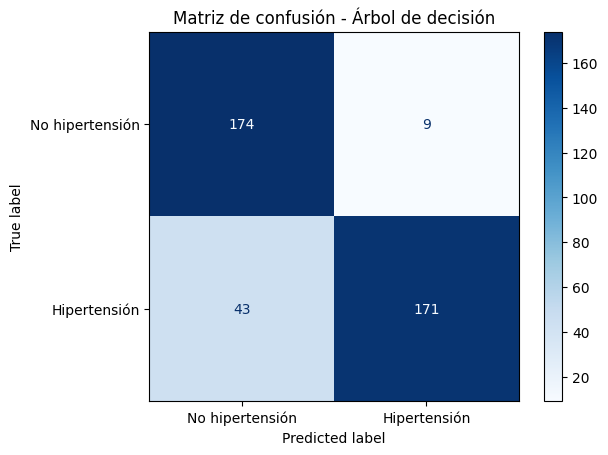

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arbol,
                              display_labels=["No hipertensión", "Hipertensión"])

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

#####A partir de la matriz de confusión del modelo de Árbol de Decisión, se puede realizar el siguiente análisis:

La matriz de confusión muestra la relación entre las clases reales y las predicciones realizadas por el modelo para identificar pacientes con riesgo de hipertensión.

En primer lugar, se observa que el modelo clasificó correctamente 174 pacientes que no presentan hipertensión, lo que corresponde a los verdaderos negativos (TN). Esto indica que el modelo tiene una buena capacidad para identificar pacientes que no se encuentran en riesgo.

Asimismo, el modelo identificó correctamente 171 pacientes con hipertensión, correspondientes a los verdaderos positivos (TP). Este resultado es especialmente relevante en el contexto del problema, ya que permite detectar pacientes que podrían requerir atención o seguimiento preventivo.

Por otro lado, se presentan 9 casos de falsos positivos (FP), es decir, pacientes que en realidad no tienen hipertensión pero que el modelo clasificó como si estuvieran en riesgo. Aunque este tipo de error puede generar alertas innecesarias, en el ámbito de la salud preventiva suele ser menos crítico que no detectar un caso real.

Finalmente, se identifican 43 falsos negativos (FN), que corresponden a pacientes que sí presentan hipertensión pero que el modelo clasificó como si no la tuvieran. Este tipo de error es particularmente importante en el contexto clínico, ya que implica que algunos pacientes en riesgo podrían no ser detectados por el modelo.

En términos generales, el modelo presenta un buen desempeño al clasificar correctamente la mayoría de los casos, tanto para pacientes con hipertensión como para aquellos sin la condición. Sin embargo, la presencia de falsos negativos sugiere que todavía existe margen de mejora en la capacidad del modelo para identificar todos los pacientes en riesgo, aspecto que es especialmente relevante en aplicaciones de medicina preventiva.

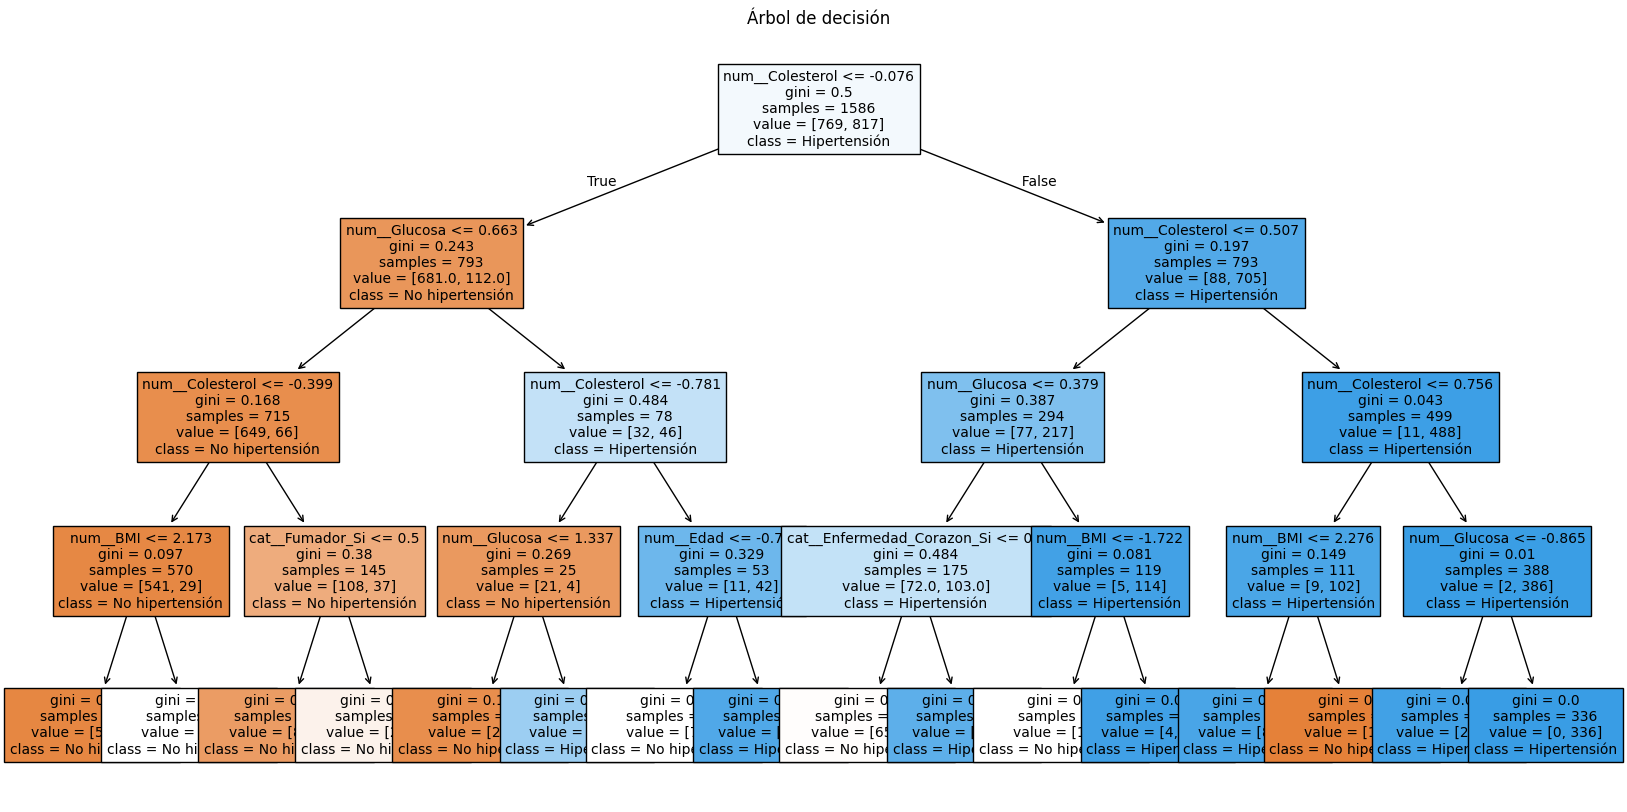

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    mejor_arbol.named_steps["modelo"],
    feature_names=feature_names,
    class_names=["No hipertensión","Hipertensión"],
    filled=True,
    max_depth=4,
    fontsize=10
)

plt.title("Árbol de decisión")
plt.show()

#####En partir del gráfico del árbol de decisión, se puede realizar el siguiente análisis interpretativo:

El árbol de decisión permite identificar las variables más relevantes que influyen en la predicción del riesgo de hipertensión, así como las reglas que el modelo utiliza para clasificar a los pacientes.

En primer lugar, se observa que la variable más importante para la primera partición del árbol es el nivel de colesterol (num_Colesterol). Esto indica que el colesterol es uno de los factores más influyentes en la clasificación del riesgo de hipertensión dentro del conjunto de datos analizado. Dependiendo de si el valor de colesterol se encuentra por debajo o por encima del umbral establecido, el modelo dirige la clasificación hacia ramas con diferentes probabilidades de hipertensión.

En la rama izquierda del árbol, cuando los niveles de colesterol son relativamente más bajos, la siguiente variable relevante es la glucosa (num_Glucosa). En este caso, valores bajos de glucosa tienden a asociarse con pacientes clasificados como no hipertensos, especialmente cuando también se observan valores moderados o bajos de índice de masa corporal (BMI) y cuando el paciente no es fumador.

Por otro lado, en la rama derecha del árbol, cuando los valores de colesterol son más altos, el modelo tiende a clasificar con mayor frecuencia a los pacientes como hipertensos. En esta parte del árbol vuelven a aparecer variables relevantes como la glucosa, el BMI, la edad y la presencia de enfermedad cardíaca, lo cual sugiere que estas características influyen significativamente en el aumento del riesgo de hipertensión.

Además, se observa que la mayoría de las hojas finales del árbol en esta rama clasifican a los pacientes como hipertensos, lo que indica que la combinación de colesterol elevado junto con otros factores metabólicos incrementa considerablemente la probabilidad de pertenecer a esta clase.

En términos generales, el árbol de decisión revela que los factores metabólicos y de estilo de vida, como el colesterol, la glucosa, el índice de masa corporal, la edad, el tabaquismo y la presencia de enfermedades cardíacas, desempeñan un papel importante en la predicción del riesgo de hipertensión. Este tipo de modelo resulta especialmente útil en contextos de salud preventiva, ya que permite interpretar fácilmente las reglas de decisión que conducen a la clasificación de los pacientes, facilitando la identificación de perfiles de mayor riesgo.

Es importante tener en cuenta que las variables numéricas fueron previamente estandarizadas mediante StandardScaler, por lo que los valores que aparecen en las reglas del árbol corresponden a valores transformados, no a las unidades originales de las variables.Este proceso transforma cada variable para que tenga una media cercana a 0 y una desviación estándar cercana a 1, como resultado, los valores mostrados en las condiciones del árbol no corresponden a las unidades originales de las variables, sino a valores estandarizados. En este contexto, los valores negativos indican que la observación se encuentra por debajo del promedio de la variable, mientras que los valores positivos indican que está por encima del promedio. Esta transformación se aplicó principalmente para mejorar el desempeño del modelo K-Nearest Neighbors, que es sensible a la escala de las variables, aunque los árboles de decisión no requieren necesariamente este tipo de escalado (tal como se habia mencionado anteriormente)

##4. Construcción del modelo K-vecinos más cercanos (KNN)

#####El algoritmo K-Nearest Neighbors (KNN) es un método de clasificación basado en distancias. Este modelo clasifica una nueva observación considerando las clases de sus K vecinos más cercanos dentro del espacio de características.

Una característica importante de este algoritmo es que su desempeño depende en gran medida del valor de K, que representa el número de vecinos utilizados para realizar la clasificación.

En este proyecto se evaluarán los siguientes valores de K:

K=[1,2,3,4,5]

Para seleccionar el mejor valor de K se utiliza GridSearchCV, evaluando cada configuración mediante validación cruzada.

###4.1 Construcción del pipeline del modelo

#####El modelo KNN se integra dentro de un pipeline junto con el preprocesador construido en la etapa anterior.

Esto garantiza que:

* las variables numéricas sean escaladas

* las variables categóricas sean codificadas

* las transformaciones se apliquen correctamente durante la validación cruzada

In [ ]:
pipeline_knn = Pipeline([
    ("prep", preprocesador),
    ("modelo", KNeighborsClassifier())
])

###4.2 Definición del espacio de búsqueda

#####Se evalúan los valores de K especificados en el enunciado.

In [ ]:
param_grid_knn = {
    "modelo__n_neighbors": [1, 2, 3, 4, 5]
}

###4.3 Aplicación de GridSearchCV

#####Se utiliza validación cruzada de 5 folds para evaluar cada valor de K.

In [ ]:
grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

#####Entrenamiento del modelo:

In [ ]:
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Edad', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI',
       'Glucosa'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                                       ('modelo', KNeighborsClassifier())]),
             n_jobs=-1, param_grid={'modelo__n_neighbors': [1, 2, 3, 4, 5]},
             scoring='accuracy')

###4.4 Mejor valor de K

In [ ]:
grid_knn.best_params_

{'modelo__n_neighbors': 5}

#####Esto permite identificar el valor de K que produce el mejor desempeño durante la validación cruzada.

###4.5 Mejor modelo encontrado

In [ ]:
mejor_knn = grid_knn.best_estimator_

###4.6 Predicciones sobre el conjunto de prueba

In [ ]:
y_pred_knn = mejor_knn.predict(X_test)

###4.7 Evaluación del modelo

#####Se calculan las métricas de desempeño que posteriormente se utilizarán para comparar los modelos.

In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)

Accuracy: 0.8841309823677582
Precision: 0.9516129032258065
Recall: 0.8271028037383178
F1-score: 0.885


Con este procedimiento se obtiene un modelo KNN optimizado, donde el valor de K ha sido seleccionado mediante validación cruzada.

###4.7 Matriz de confusion

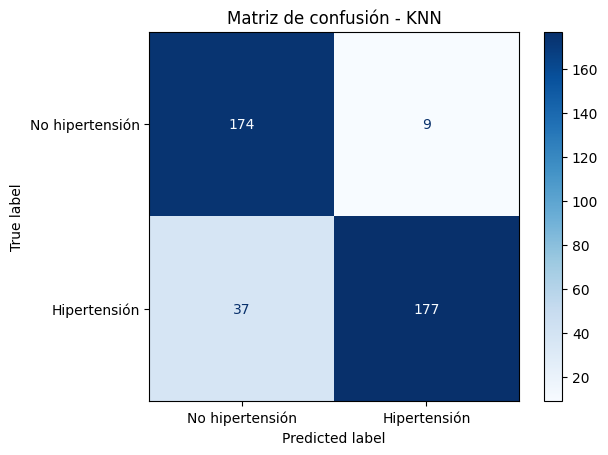

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=["No hipertensión", "Hipertensión"])

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - KNN")
plt.show()

##### La matriz de confusión permite analizar con mayor detalle el desempeño del modelo K-Nearest Neighbors (KNN) al clasificar pacientes con y sin hipertensión. A partir de los resultados obtenidos se observa lo siguiente:

* 174 verdaderos negativos (TN): pacientes correctamente clasificados como no hipertensos.

* 177 verdaderos positivos (TP): pacientes correctamente identificados como hipertensos.

* 9 falsos positivos (FP): pacientes que el modelo clasificó como hipertensos cuando en realidad no lo eran.

* 37 falsos negativos (FN): pacientes que presentan hipertensión pero que el modelo no logró identificar.

En términos generales, el modelo muestra un buen desempeño al identificar correctamente ambas clases, lo cual es consistente con los valores de exactitud cercanos al 88% obtenidos previamente.

Desde una perspectiva empresarial y clínica, es importante analizar el impacto de los errores del modelo. En particular, los falsos negativos (37 casos) representan pacientes con hipertensión que no fueron detectados por el modelo. Este tipo de error es especialmente relevante en el contexto de medicina preventiva, ya que podría implicar que algunos pacientes en riesgo no reciban seguimiento o intervención temprana.

Por otro lado, el número de falsos positivos es relativamente bajo (9 casos), lo que indica que el modelo rara vez clasifica erróneamente a un paciente sano como hipertenso. En un contexto clínico, este tipo de error suele ser menos crítico, ya que generalmente solo implicaría evaluaciones médicas adicionales.

En conjunto, estos resultados sugieren que el modelo KNN presenta un desempeño adecuado para apoyar procesos de identificación temprana de pacientes con riesgo de hipertensión, aunque sería deseable seguir mejorando la capacidad del modelo para reducir el número de falsos negativos, fortaleciendo así su utilidad en estrategias de prevención cardiovascular.

##5. Comparación del rendimiento de los modelos

#####Una vez entrenados los modelos de Árbol de Decisión y K-Nearest Neighbors (KNN), se procede a evaluar su desempeño utilizando el conjunto de prueba.

Para esta evaluación se utilizan las siguientes métricas:

* Exactitud (Accuracy): proporción de predicciones correctas sobre el total de observaciones.

* Precisión (Precision): proporción de predicciones positivas correctas.

* Recall (Sensibilidad): proporción de casos positivos correctamente identificados.

* F1-score: media armónica entre precisión y recall.

Estas métricas permiten evaluar el desempeño de los modelos desde diferentes perspectivas, especialmente en problemas de clasificación.

###5.1 Construcción de la tabla comparativa

In [ ]:
resultados = pd.DataFrame({

    "Modelo": ["Árbol de Decisión", "KNN"],
    "Accuracy": [accuracy_arbol, accuracy_knn],
    "Precision": [precision_arbol, precision_knn],
    "Recall": [recall_arbol, recall_knn],
    "F1-score": [f1_arbol, f1_knn]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Árbol de Decisión,0.869018,0.950000,0.799065,0.86802
1,KNN,0.884131,0.951613,0.827103,0.88500


###5.2 Interpretación de la tabla comparativa

#####La tabla presenta el desempeño de los modelos de Árbol de Decisión y K-Nearest Neighbors (KNN) evaluados sobre el conjunto de prueba utilizando las métricas de exactitud, precisión, recall y F1-score.

En términos de exactitud (accuracy), el modelo KNN presenta un valor ligeramente superior (0.884) en comparación con el árbol de decisión (0.869). Esto indica que el modelo basado en vecinos cercanos logra clasificar correctamente una proporción mayor de observaciones del conjunto de prueba.

Respecto a la precisión (precision), ambos modelos presentan valores elevados cercanos a 0.95, lo que indica que cuando cualquiera de los modelos predice que un paciente tiene hipertensión, la probabilidad de que esta predicción sea correcta es alta. No obstante, el modelo KNN obtiene un valor ligeramente superior (0.951) frente al árbol de decisión (0.950).

En cuanto al recall, que mide la capacidad del modelo para identificar correctamente a los pacientes con hipertensión, el modelo KNN nuevamente presenta un mejor desempeño (0.827) en comparación con el árbol de decisión (0.799). Esto sugiere que el modelo KNN logra detectar una mayor proporción de pacientes que realmente presentan hipertensión.

Finalmente, al considerar el F1-score, que combina precisión y recall, el modelo KNN también obtiene un valor ligeramente superior (0.885) frente al árbol de decisión (0.868). Esto indica que el modelo KNN mantiene un mejor equilibrio entre ambas métricas.

Una posible explicación de este resultado es que el algoritmo K-Nearest Neighbors es especialmente sensible a la escala de las variables, ya que su funcionamiento se basa en el cálculo de distancias entre observaciones. En este proyecto se aplicó un proceso de estandarización (StandardScaler) dentro del pipeline de preprocesamiento, lo cual permitió que todas las variables numéricas tuvieran magnitudes comparables. Este escalado favorece particularmente a los modelos basados en distancia, como KNN, mejorando su capacidad para identificar patrones en los datos.

En conjunto, aunque ambos modelos presentan un desempeño adecuado, el modelo KNN muestra un rendimiento ligeramente superior en todas las métricas evaluadas, lo que sugiere que podría ser el modelo más adecuado para la predicción del riesgo de hipertensión en este conjunto de datos.

##6. Estimación de intervalos de confianza mediante Bootstrapping

###6.1 ¿Qué es Bootstrapping?

#####El bootstrapping es una técnica estadística basada en remuestreo con reemplazo, utilizada para estimar la distribución de una estadística cuando no se conoce su distribución teórica.

En el contexto de aprendizaje automático, esta técnica permite estimar la variabilidad de una métrica de desempeño, como la exactitud, generando múltiples muestras a partir del conjunto de prueba.

El procedimiento consiste en:

1. Tomar una muestra aleatoria del conjunto de prueba con reemplazo.

2. Calcular la métrica de interés (en este caso, accuracy).

3. Repetir este proceso muchas veces.

4. Construir una distribución de la métrica obtenida.

5. Calcular el intervalo de confianza del 95% utilizando percentiles.

Este enfoque permite estimar qué tan estable es el desempeño del modelo frente a variaciones en los datos.

###6.2 Implementación del Bootstrapping

#####Dado que el modelo K-Nearest Neighbors presentó el mejor desempeño en términos de exactitud, recall y F1-score, se seleccionó este modelo para estimar el intervalo de confianza de la métrica de exactitud utilizando la técnica de bootstrapping.

In [ ]:
n_bootstrap = 1000
scores = []

np.random.seed(77)

for i in range(n_bootstrap):

    indices = np.random.choice(len(X_test), size=len(X_test), replace=True)

    X_sample = X_test.iloc[indices]
    y_sample = y_test.iloc[indices]

    y_pred = mejor_knn.predict(X_sample)

    score = accuracy_score(y_sample, y_pred)

    scores.append(score)

#####Aquí:

* Se generan 1000 muestras bootstrap

* Cada muestra tiene el mismo tamaño que el conjunto de test

* Se calcula accuracy en cada iteración

###6.3 Cálculo del intervalo de confianza

In [ ]:
lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)

print("Intervalo de confianza (95%):")
print(lower, upper)

Intervalo de confianza (95%):
0.8538413098236776 0.9144206549118388


#####Esto calcula los percentiles 2.5 y 97.5, que corresponden al intervalo de confianza del 95%.

###6.4 Visualización de la distribución

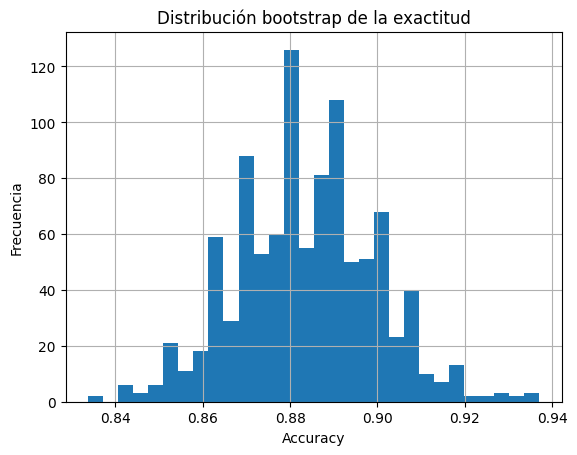

In [ ]:
plt.hist(scores, bins=30)
plt.title("Distribución bootstrap de la exactitud")
plt.xlabel("Accuracy")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

###6.5 Interpretación de la distribución bootstrap de la exactitud

#####La figura muestra la distribución de los valores de exactitud (accuracy) obtenidos a partir de las muestras generadas mediante la técnica de bootstrapping, aplicada al modelo K-Nearest Neighbors (KNN). Cada barra del histograma representa la frecuencia con la que se obtuvo un determinado valor de exactitud al evaluar el modelo sobre diferentes muestras del conjunto de prueba generadas con reemplazo.

Se observa que la mayor parte de los valores de exactitud se concentran aproximadamente entre 0.87 y 0.89, con un valor central cercano a 0.88, lo cual coincide con la exactitud obtenida previamente al evaluar el modelo KNN sobre el conjunto de prueba original.

La forma relativamente simétrica y concentrada de la distribución indica que el desempeño del modelo presenta una variabilidad moderada, lo que sugiere que pequeñas variaciones en los datos de prueba no producen cambios significativos en el rendimiento del modelo. Esto es una señal positiva respecto a la estabilidad del modelo.

A partir de esta distribución se calcula el intervalo de confianza del 95%, utilizando los percentiles 2.5 y 97.5 de los valores obtenidos mediante bootstrapping. Este intervalo representa el rango dentro del cual es probable que se encuentre la verdadera exactitud del modelo cuando se aplique a nuevas muestras provenientes de la misma población.

En el contexto del problema, estos resultados indican que el modelo KNN mantiene un desempeño consistente para la predicción del riesgo de hipertensión, con valores de exactitud cercanos al 88%, lo que sugiere que el modelo posee una capacidad predictiva adecuada para apoyar procesos de identificación temprana de pacientes en riesgo.

Además, el hecho de que la distribución de exactitud se mantenga relativamente concentrada alrededor de este valor refuerza la idea de que el modelo es robusto frente a variaciones en los datos, lo cual es una característica deseable en aplicaciones relacionadas con la toma de decisiones en entornos clínicos o empresariales del sector salud.

##7. Árboles de decisión, hasta con una profundidad de tres (3)

In [ ]:
feature_names = mejor_arbol.named_steps["prep"].get_feature_names_out()

In [ ]:
tree_rules = export_text(
    mejor_arbol.named_steps["modelo"],
    feature_names=list(feature_names),
    max_depth=3
)

print(tree_rules)

|--- num__Colesterol <= -0.08
|   |--- num__Glucosa <= 0.66
|   |   |--- num__Colesterol <= -0.40
|   |   |   |--- num__BMI <= 2.17
|   |   |   |   |--- class: 0
|   |   |   |--- num__BMI >  2.17
|   |   |   |   |--- class: 0
|   |   |--- num__Colesterol >  -0.40
|   |   |   |--- cat__Fumador_Si <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Fumador_Si >  0.50
|   |   |   |   |--- class: 0
|   |--- num__Glucosa >  0.66
|   |   |--- num__Colesterol <= -0.78
|   |   |   |--- num__Glucosa <= 1.34
|   |   |   |   |--- class: 0
|   |   |   |--- num__Glucosa >  1.34
|   |   |   |   |--- class: 1
|   |   |--- num__Colesterol >  -0.78
|   |   |   |--- num__Edad <= -0.76
|   |   |   |   |--- class: 0
|   |   |   |--- num__Edad >  -0.76
|   |   |   |   |--- class: 1
|--- num__Colesterol >  -0.08
|   |--- num__Colesterol <= 0.51
|   |   |--- num__Glucosa <= 0.38
|   |   |   |--- cat__Enfermedad_Corazon_Si <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cat__Enfermedad_Corazon_

A partir del árbol generado se observa que las variables que aparecen en los niveles superiores del árbol son:

* Colesterol

* Glucosa

* Índice de masa corporal (BMI)

La presencia de estas variables en los niveles superiores indica que tienen una mayor influencia en la clasificación del riesgo de hipertensión.

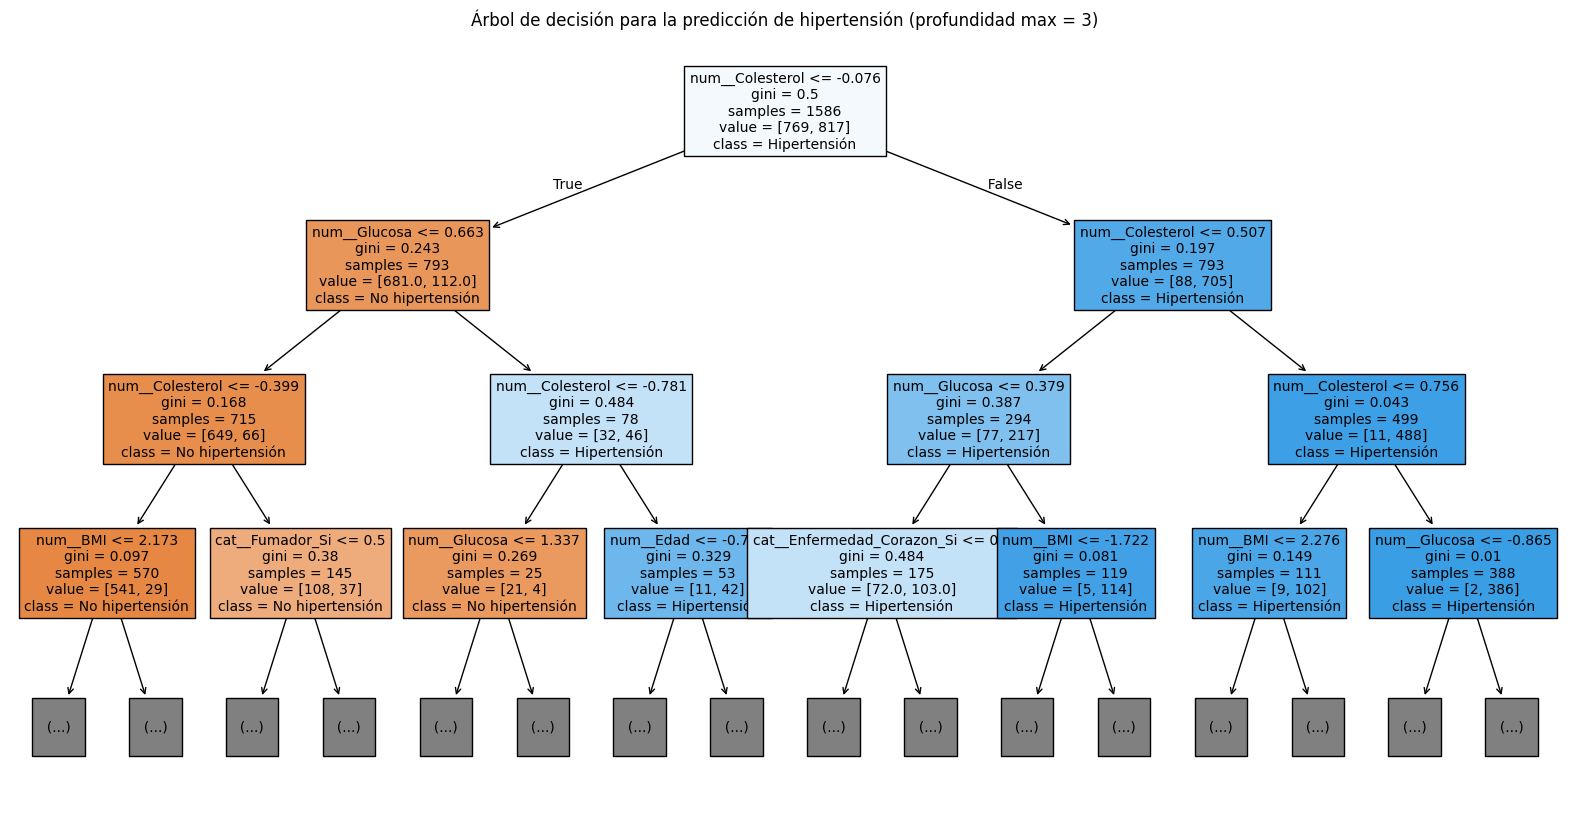

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    mejor_arbol.named_steps["modelo"],
    feature_names=feature_names,
    class_names=["No hipertensión","Hipertensión"],
    filled=True,
    max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión para la predicción de hipertensión (profundidad max = 3)")
plt.show()

En la visualización del árbol de decisión se observan algunos nodos representados en color gris al final de ciertas ramas. Estos nodos indican que el árbol continúa creciendo más allá del nivel mostrado, pero que su representación ha sido truncada deliberadamente.

Esto ocurre porque la visualización se generó limitando la profundidad máxima del árbol a tres niveles (max_depth = 3), con el objetivo de facilitar la interpretación del modelo. De esta manera, solo se muestran las decisiones más relevantes que se encuentran en los niveles superiores del árbol, mientras que las divisiones posteriores no se representan gráficamente.

En términos prácticos, los nodos grises indican que existen subdivisiones adicionales del árbol que no se muestran en la visualización, pero que sí forman parte del modelo completo utilizado para realizar las predicciones. Este enfoque es útil porque permite identificar las variables más influyentes en las primeras decisiones del modelo, evitando una representación demasiado compleja que dificultaría la interpretación del árbol.

##8. Análisis de resultados

###1. ¿Qué puedes decir de los valores de recall y precisión para cada una de las clases en cada modelo? ¿Cuál métrica es más importante?

Los resultados obtenidos muestran que ambos modelos presentan niveles elevados de precisión, cercanos a 0.95, lo que indica que cuando el modelo clasifica a un paciente como hipertenso, existe una alta probabilidad de que esta predicción sea correcta. Esto significa que los modelos generan relativamente pocos falsos positivos.

En cuanto al recall, el modelo KNN presenta un mejor desempeño (0.83) en comparación con el árbol de decisión (0.80), lo que indica que el modelo KNN logra identificar una mayor proporción de pacientes que realmente presentan hipertensión.

En el contexto de medicina preventiva, el recall suele ser la métrica más relevante, ya que un falso negativo implica no identificar a un paciente que realmente está en riesgo de hipertensión. Esto podría retrasar intervenciones médicas o estrategias preventivas que podrían evitar complicaciones cardiovasculares a futuro.

Por esta razón, desde una perspectiva clínica y empresarial orientada a la detección temprana, resulta más importante priorizar modelos que presenten mayor recall, incluso si esto implica aceptar un número ligeramente mayor de falsos positivos.

###2. ¿Consideras que el rendimiento de los modelos es adecuado? ¿Cómo podrían mejorarse los resultados?

Los resultados obtenidos muestran que ambos modelos alcanzan niveles de exactitud cercanos al 88%, lo que indica una capacidad predictiva adecuada para identificar pacientes con riesgo de hipertensión dentro del conjunto de datos analizado.

Desde una perspectiva empresarial en el sector salud, este nivel de desempeño puede ser considerado aceptable como herramienta de apoyo para procesos de detección temprana, especialmente en escenarios donde se busca priorizar pacientes que requieren seguimiento médico.

No obstante, existen varias estrategias que podrían mejorar el desempeño del modelo:

* Incorporar más variables clínicas relevantes, como presión arterial histórica, hábitos alimenticios o antecedentes médicos más detallados.

* Aumentar el tamaño del dataset, lo que permitiría entrenar modelos más robustos.

* Probar algoritmos más avanzados como Random Forest, Gradient Boosting o XGBoost, que suelen capturar relaciones más complejas entre variables.

* Realizar ingeniería de características (feature engineering) para generar variables derivadas que representen mejor los factores de riesgo asociados a la hipertensión.

Estas mejoras podrían incrementar la capacidad predictiva del modelo y mejorar su aplicabilidad en sistemas de apoyo a decisiones clínicas.

###3. ¿Cuáles son las variables más significativas según el árbol de decisión? ¿Cómo puede ayudar este conocimiento?

Una de las ventajas del modelo de árbol de decisión es su capacidad de interpretación, ya que permite identificar las variables que influyen con mayor peso en la clasificación del riesgo de hipertensión.

De acuerdo con las reglas generadas por el árbol, variables como colesterol, índice de masa corporal (BMI) y niveles de glucosa tienden a aparecer en los niveles superiores del árbol, lo que indica que tienen un papel importante en la toma de decisiones del modelo.

Desde un enfoque empresarial en el sector salud, esta información puede ser altamente valiosa, ya que permite:

* identificar factores de riesgo prioritarios asociados a la hipertensión

* diseñar programas de prevención dirigidos a poblaciones de mayor riesgo

* optimizar campañas de educación en salud

* apoyar a profesionales médicos en la identificación temprana de pacientes vulnerables

De esta manera, el modelo no solo aporta capacidad predictiva, sino también conocimiento accionable para la toma de decisiones en salud preventiva.

###4. Si ambos modelos presentan resultados similares, ¿cuál seleccionarías considerando el contexto clínico?

Aunque ambos modelos presentan resultados similares, el modelo KNN muestra un desempeño ligeramente superior en términos de exactitud, recall y F1-score, lo que sugiere que tiene una mayor capacidad para identificar correctamente a los pacientes con hipertensión dentro del conjunto de datos analizado.

Por esta razón, desde una perspectiva orientada al desempeño predictivo, el modelo KNN podría ser seleccionado como el modelo principal para la identificación de pacientes en riesgo.

No obstante, el modelo de árbol de decisión mantiene una ventaja importante en términos de interpretabilidad, ya que permite comprender fácilmente qué variables influyen en la predicción.

Por lo tanto, en un entorno empresarial del sector salud, ambos modelos podrían utilizarse de forma complementaria:

* KNN para mejorar la capacidad de predicción.

* Árbol de decisión para explicar los factores de riesgo asociados a la hipertensión.

Esta combinación permitiría equilibrar precisión predictiva e interpretabilidad clínica.

###5. ¿Qué indica el intervalo de confianza sobre la estabilidad y confiabilidad del modelo?

El intervalo de confianza estimado mediante la técnica de bootstrapping permite evaluar la estabilidad del modelo frente a diferentes muestras de datos.

Los resultados muestran que la mayor parte de los valores de exactitud obtenidos se concentran alrededor de 0.88, con un rango relativamente estrecho entre aproximadamente 0.87 y 0.89. Esto indica que el modelo mantiene un desempeño relativamente consistente incluso cuando se evalúa sobre diferentes muestras generadas a partir del conjunto de prueba.

Desde una perspectiva empresarial, esto sugiere que el modelo presenta una buena estabilidad y confiabilidad, lo cual es fundamental cuando se pretende utilizar modelos predictivos como herramientas de apoyo en la toma de decisiones clínicas o en programas de prevención de enfermedades.

En otras palabras, el modelo no solo presenta un buen desempeño promedio, sino que también muestra baja variabilidad en sus resultados, lo que aumenta la confianza en su aplicación en contextos reales.

#Referencias

#####American Heart Association. (2023). About cholesterol. https://www.heart.org/en/health-topics/cholesterol/about-cholesterol

World Health Organization. (2024). Obesity and overweight. https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight

National Sleep Foundation. (2020). How much sleep do we really need? https://www.sleepfoundation.org/how-sleep-works/how-much-sleep-do-we-really-need

World Health Organization. (2024). Obesity and overweight. https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight

#Crear .html

In [ ]:
!jupyter nbconvert --to html "project_etapa2.ipynb"

[NbConvertApp] Converting notebook project_etapa2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 1700862 bytes to project_etapa2.html
